In [8]:
import numpy as np
import seaborn as sns 
import pandas as pd
import matplotlib.pyplot as plt 
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier
import pickle 




In [9]:
df=pd.read_csv('music_survey_dataset.csv')
df.columns

Index(['Timestamp', 'Age', 'Primary streaming service', 'Hours per day',
       'While working', 'Instrumentalist', 'Composer', 'Fav genre',
       'Exploratory', 'Foreign languages', 'BPM', 'Frequency [Classical]',
       'Frequency [Country]', 'Frequency [EDM]', 'Frequency [Folk]',
       'Frequency [Gospel]', 'Frequency [Hip hop]', 'Frequency [Jazz]',
       'Frequency [K pop]', 'Frequency [Latin]', 'Frequency [Lofi]',
       'Frequency [Metal]', 'Frequency [Pop]', 'Frequency [R&B]',
       'Frequency [Rap]', 'Frequency [Rock]', 'Frequency [Video game music]',
       'Anxiety', 'Depression', 'Insomnia', 'OCD', 'Music effects',
       'Permissions'],
      dtype='str')

In [10]:
df.head()

,Timestamp,Age,Primary streaming service,Hours per day,While working,Instrumentalist,Composer,Fav genre,Exploratory,Foreign languages,...,Frequency [R&B],Frequency [Rap],Frequency [Rock],Frequency [Video game music],Anxiety,Depression,Insomnia,OCD,Music effects,Permissions
0,8/27/2022 19:29:02,18.0,Spotify,3.0,Yes,Yes,Yes,Latin,Yes,Yes,...,Sometimes,Very frequently,Never,Sometimes,3.0,0.0,1.0,0.0,NaN,I understand.
1,8/27/2022 19:57:31,63.0,Pandora,1.5,Yes,No,No,Rock,Yes,No,...,Sometimes,Rarely,Very frequently,Rarely,7.0,2.0,2.0,1.0,NaN,I understand.
2,8/27/2022 21:28:18,18.0,Spotify,4.0,No,No,No,Video game music,No,Yes,...,Never,Rarely,Rarely,Very frequently,7.0,7.0,10.0,2.0,No effect,I understand.
3,8/27/2022 21:40:40,61.0,YouTube Music,2.5,Yes,No,Yes,Jazz,Yes,Yes,...,Sometimes,Never,Never,Never,9.0,7.0,3.0,3.0,Improve,I understand.
4,8/27/2022 21:54:47,18.0,Spotify,4.0,Yes,No,No,R&B,Yes,No,...,Very frequently,Very frequently,Never,Rarely,7.0,2.0,5.0,9.0,Improve,I understand.


In [11]:
df =df.dropna(subset=["Music effects", "BPM"])#supprimer les NaN des 
#Entre temp on avait supprimer les colonnes Timestamps,Primary streaming service, permissions avec df=df.drop(columns=['Timestam', 'prideservice])
df = df.drop(columns=['Timestamp','Primary streaming service'])
df = df.dropna(axis=1, how='all')# supprimer toute les colonne qui n'ont pas de valeurs 
df.head(15)

,Age,Hours per day,While working,Instrumentalist,Composer,Fav genre,Exploratory,Foreign languages,BPM,Frequency [Classical],...,Frequency [R&B],Frequency [Rap],Frequency [Rock],Frequency [Video game music],Anxiety,Depression,Insomnia,OCD,Music effects,Permissions
2,18.0,4.0,No,No,No,Video game music,No,Yes,132.0,Never,...,Never,Rarely,Rarely,Very frequently,7.0,7.0,10.0,2.0,No effect,I understand.
3,61.0,2.5,Yes,No,Yes,Jazz,Yes,Yes,84.0,Sometimes,...,Sometimes,Never,Never,Never,9.0,7.0,3.0,3.0,Improve,I understand.
4,18.0,4.0,Yes,No,No,R&B,Yes,No,107.0,Never,...,Very frequently,Very frequently,Never,Rarely,7.0,2.0,5.0,9.0,Improve,I understand.
5,18.0,5.0,Yes,Yes,Yes,Jazz,Yes,Yes,86.0,Rarely,...,Very frequently,Very frequently,Very frequently,Never,8.0,8.0,7.0,7.0,Improve,I understand.
6,18.0,3.0,Yes,Yes,No,Video game music,Yes,Yes,66.0,Sometimes,...,Rarely,Never,Never,Sometimes,4.0,8.0,6.0,0.0,Improve,I understand.
7,21.0,1.0,Yes,No,No,K pop,Yes,Yes,95.0,Never,...,Sometimes,Rarely,Never,Rarely,5.0,3.0,5.0,3.0,Improve,I understand.
8,19.0,6.0,Yes,No,No,Rock,No,No,94.0,Never,...,Never,Never,Very frequently,Never,2.0,0.0,0.0,0.0,Improve,I understand.
9,18.0,1.0,Yes,No,No,R&B,Yes,Yes,155.0,Rarely,...,Sometimes,Rarely,Sometimes,Sometimes,2.0,2.0,5.0,1.0,Improve,I understand.
11,19.0,8.0,Yes,No,No,EDM,Yes,No,125.0,Rarely,...,Rarely,Sometimes,Rarely,Rarely,1.0,0.0,0.0,1.0,Improve,I understand.
13,19.0,2.0,Yes,No,No,Country,Yes,No,88.0,Never,...,Never,Very frequently,Never,Never,2.0,1.0,2.0,0.0,Improve,I understand.


In [12]:
#changer le nom d'une colonne 
df = df.rename(columns={'Frequency [Video game music]': 'Frequency [Vgm]'})
df = df.drop(columns=['Fav genre'])


In [13]:
df = df.drop(columns=['Permissions'])

In [14]:
#afficher tou les contenant de chaque celle d'une colonne 
pd.set_option("display.max_colwidth",None)
print(df["Music effects"])

2      No effect
3        Improve
4        Improve
5        Improve
6        Improve
         ...    
731      Improve
732      Improve
733      Improve
734      Improve
735      Improve
Name: Music effects, Length: 624, dtype: str


In [15]:
#No=0, yes =1
df = df.replace({'Yes':1, 'No':0})
#Never=0; rarely=1; sometimes=2 ; very_fréquently=3
df = df.replace({'Never':0, 'Rarely':1, 'Sometimes':2, 'Very frequently':3})
# No-effect=0, improve=1
df = df.replace({'No effect':0,'Worsen':1,'Improve':2})
# Conversion en int (si toutes les valeurs sont numériques après remplacement)
try:
    df = df.astype(int)
except ValueError:
    # Si certaines colonnes ne sont pas convertibles, on les ignore
    for col in df.columns:
        try:
            df[col] = df[col].astype(int)
        except ValueError:
            pass

print("\nAprès transformation :")
df.head()




Après transformation :


,Age,Hours per day,While working,Instrumentalist,Composer,Exploratory,Foreign languages,BPM,Frequency [Classical],Frequency [Country],...,Frequency [Pop],Frequency [R&B],Frequency [Rap],Frequency [Rock],Frequency [Vgm],Anxiety,Depression,Insomnia,OCD,Music effects
2,18,4,0,0,0,0,1,132,0,0,...,1,0,1,1,3,7,7,10,2,0
3,61,2,1,0,1,1,1,84,2,0,...,2,2,0,0,0,9,7,3,3,2
4,18,4,1,0,0,1,0,107,0,0,...,2,3,3,0,1,7,2,5,9,2
5,18,5,1,1,1,1,1,86,1,2,...,3,3,3,3,0,8,8,7,7,2
6,18,3,1,1,0,1,1,66,2,0,...,1,1,0,0,2,4,8,6,0,2


In [16]:
df.info()

<class 'pandas.DataFrame'>
Index: 624 entries, 2 to 735
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Age                    624 non-null    int64 
 1   Hours per day          624 non-null    int64 
 2   While working          623 non-null    object
 3   Instrumentalist        621 non-null    object
 4   Composer               624 non-null    int64 
 5   Exploratory            624 non-null    int64 
 6   Foreign languages      621 non-null    object
 7   BPM                    624 non-null    int64 
 8   Frequency [Classical]  624 non-null    int64 
 9   Frequency [Country]    624 non-null    int64 
 10  Frequency [EDM]        624 non-null    int64 
 11  Frequency [Folk]       624 non-null    int64 
 12  Frequency [Gospel]     624 non-null    int64 
 13  Frequency [Hip hop]    624 non-null    int64 
 14  Frequency [Jazz]       624 non-null    int64 
 15  Frequency [K pop]      624 non-null    

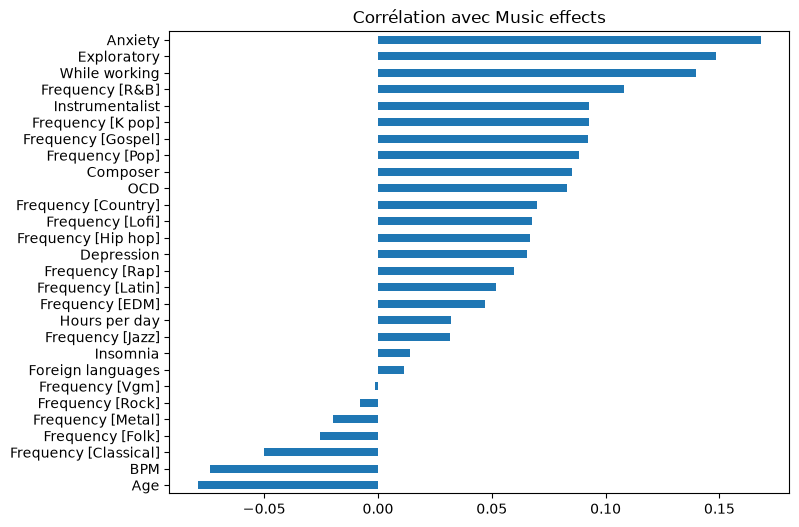

In [17]:
corr_target = df.corr()['Music effects'].drop('Music effects').sort_values()
corr_target.plot(kind='barh', figsize=(8,6))
plt.title('Corrélation avec Music effects')
plt.show()

In [18]:
features = ['Anxiety', 'Exploratory','While working', 'Frequency [R&B]', 'Frequency [K pop]','Frequency [Pop]',
            'Instrumentalist', 'Composer']

df_sans_nan = df.dropna(subset=features + ['Music effects'])

X = df_sans_nan[features]
y = df_sans_nan['Music effects']

#X=df[features]
#y=df['Music effects']

In [19]:
# division des données en donnée d'entrainement et de test 
#Le paramètre random_state sert à contrôler le caractère aléatoire dans certaines opérations de scikit-learn (et plus largement en machine learning) afin de rendre les résultats reproductibles
X_train, X_test, y_train, y_test  = train_test_split(X,y,test_size=0.25,random_state=42)

In [20]:
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print("Accuracy", rf.score(X_test,y_test))
print(classification_report(y_test, y_pred))

Accuracy 0.7161290322580646
              precision    recall  f1-score   support

           0       0.42      0.48      0.45        33
           1       0.00      0.00      0.00         2
           2       0.85      0.79      0.82       120

    accuracy                           0.72       155
   macro avg       0.42      0.43      0.42       155
weighted avg       0.75      0.72      0.73       155



In [21]:
prob=rf.predict_proba(X_test[:5])
print("\n probabilité\n", prob )


 probabilité
 [[0.43333333 0.03       0.53666667]
 [0.6        0.01       0.39      ]
 [0.9045     0.         0.0955    ]
 [0.42666667 0.01       0.56333333]
 [0.23133333 0.02       0.74866667]]


In [22]:
with open ('model/rf.bin', 'wb') as f_out :
    pickle.dump(rf, f_out)